# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who - Marketing manager <br>
What - Which channels / segments drive conversions and where spend is wasted (and whether conversions are imbalanced) <br>
How - Conversion rate by platform/tool/segment and distribution of conversions

# 3. Homework - work with your own data

In [32]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [33]:
# Additional Imports
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [34]:
# Download the "Predict Conversion in Digital Marketing Dataset" from Kaggle and load it into a pandas DataFrame - https://www.kaggle.com/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset

path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")
print("Path to dataset files:", path)

# Contruct the full path to the CSV file (update the filename if necessary)
csv_file = os.path.join(path, "digital_marketing_campaign_dataset.csv")

# Read the dataset into a DataFrame
df_digital_marketing = pd.read_csv(csv_file)


Path to dataset files: C:\Users\David\.cache\kagglehub\datasets\rabieelkharoua\predict-conversion-in-digital-marketing-dataset\versions\1


In [35]:
# Display the first few rows of the DataFrame
df_digital_marketing.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [36]:
# info about the "Predict Conversion in Digital Marketing Dataset"
df_digital_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [37]:
# describe the "Predict Conversion in Digital Marketing Dataset"
df_digital_marketing.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [38]:
# Missing value analysis

# Missing Value Count
missing_counts = df_digital_marketing.isnull().sum()
print("Missing values in each column:\n", missing_counts)

print("\n")

# Percentage of missing values in each column
missing_percentages = df_digital_marketing.isnull().mean() * 100
print("Percentage of missing values in each column:\n", missing_percentages)

print("\n")

# Total Missing Values in Entire Dataset
total_missing = df_digital_marketing.isnull().sum().sum()
print("Total missing values in the dataset:", total_missing)

Missing values in each column:
 CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


Percentage of missing values in each column:
 CustomerID             0.0
Age                    0.0
Gender                 0.0
Income                 0.0
CampaignChannel        0.0
CampaignType           0.0
AdSpend                0.0
ClickThroughRate       0.0
ConversionRate         0.0
WebsiteVisits          0.0
PagesPerVisit          0.0
TimeOnSite             0.0
SocialShares           0.0
EmailOpens             0.0
EmailClicks            0.0
Pr

In [47]:
# Duplicate Analysis

# Check for duplicate rows
duplicate_count = df_digital_marketing.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

print("\n")

# view the duplicate rows
duplicates = df_digital_marketing[df_digital_marketing.duplicated()]
print("Duplicate rows:\n", duplicates)

# Check duplicates for specific columns (e.g., 'CustomerID')
duplicate_customer_ids = df_digital_marketing['CustomerID'].duplicated().sum()
print("Duplicate 'CustomerID's:\n", duplicate_customer_ids)
print("Number of unique 'CustomerID's:", df_digital_marketing['CustomerID'].nunique()) # No duplicates are expected in 'CustomerID'

# Remove Duplicates
df_digital_marketing_cleaned = df_digital_marketing.drop_duplicates()
print("Number of rows after removing duplicates:", len(df_digital_marketing_cleaned))

Number of duplicate rows: 0


Duplicate rows:
 Empty DataFrame
Columns: [CustomerID, Age, Gender, Income, CampaignChannel, CampaignType, AdSpend, ClickThroughRate, ConversionRate, WebsiteVisits, PagesPerVisit, TimeOnSite, SocialShares, EmailOpens, EmailClicks, PreviousPurchases, LoyaltyPoints, AdvertisingPlatform, AdvertisingTool, Conversion]
Index: []
Duplicate 'CustomerID's:
 0
Number of unique 'CustomerID's: 8000
Number of rows after removing duplicates: 8000


In [40]:
# Detect Outliers for all Numberic Columns
numeric_cols = df_digital_marketing_cleaned.select_dtypes(include=[np.number]).columns
if 'CustomerID' in numeric_cols:
    numeric_cols = numeric_cols.drop('CustomerID')  # Exclude 'CustomerID' if it's numeric

for col in numeric_cols:
    Q1 = df_digital_marketing_cleaned[col].quantile(0.25)
    Q3 = df_digital_marketing_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_digital_marketing_cleaned[(df_digital_marketing_cleaned[col] < lower_bound) | (df_digital_marketing_cleaned[col] > upper_bound)]
    print(f"Number of outliers in '{col}':", len(outliers))

Number of outliers in 'Age': 0
Number of outliers in 'Income': 0
Number of outliers in 'AdSpend': 0
Number of outliers in 'ClickThroughRate': 0
Number of outliers in 'ConversionRate': 0
Number of outliers in 'WebsiteVisits': 0
Number of outliers in 'PagesPerVisit': 0
Number of outliers in 'TimeOnSite': 0
Number of outliers in 'SocialShares': 0
Number of outliers in 'EmailOpens': 0
Number of outliers in 'EmailClicks': 0
Number of outliers in 'PreviousPurchases': 0
Number of outliers in 'LoyaltyPoints': 0
Number of outliers in 'Conversion': 988


In [41]:
# Check for invalid Ages
invalid_ages = df_digital_marketing_cleaned[(df_digital_marketing_cleaned['Age'] < 0) | (df_digital_marketing_cleaned['Age'] > 120)]
print("Number of invalid ages:", len(invalid_ages))

Number of invalid ages: 0


In [42]:
# Check for invalid TimeOnSite values
invalid_time_on_site = df_digital_marketing_cleaned[df_digital_marketing_cleaned['TimeOnSite'] < 0]
print("Number of invalid TimeOnSite values:", len(invalid_time_on_site))

Number of invalid TimeOnSite values: 0


In [43]:
# Check the value counts of the 'Conversion' column
conversion_dist = df_digital_marketing["Conversion"].value_counts(dropna=False)
conversion_pct = df_digital_marketing["Conversion"].value_counts(normalize=True, dropna=False) * 100
print(conversion_dist)
print(conversion_pct.round(2))

Conversion
1    7012
0     988
Name: count, dtype: int64
Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


In [44]:
# mean, median, mode for numerical columns
numerical_cols = df_digital_marketing_cleaned.select_dtypes(include=[np.number]).columns.tolist()
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')  # Exclude 'CustomerID' if it's numeric    
    
for col in numerical_cols:
    mean = df_digital_marketing_cleaned[col].mean()
    median = df_digital_marketing_cleaned[col].median()
    mode = df_digital_marketing_cleaned[col].mode()[0]
    print(f"Column: {col} | Mean: {mean} | Median: {median} | Mode: {mode}")

Column: Age | Mean: 43.6255 | Median: 43.0 | Mode: 64
Column: Income | Mean: 84664.19675 | Median: 84926.5 | Mode: 50268
Column: AdSpend | Mean: 5000.944830424953 | Median: 5013.440043527517 | Mode: 100.05481308980612
Column: ClickThroughRate | Mean: 0.15482864915095626 | Median: 0.1545054889779906 | Mode: 0.010004853514801
Column: ConversionRate | Mean: 0.10438873502114548 | Median: 0.10404646355838995 | Mode: 0.0100177828330717
Column: WebsiteVisits | Mean: 24.751625 | Median: 25.0 | Mode: 25
Column: PagesPerVisit | Mean: 5.549299217259862 | Median: 5.534256645149098 | Mode: 1.0004278505451207
Column: TimeOnSite | Mean: 7.72771816251526 | Median: 7.682956376265835 | Mode: 0.5016690842279518
Column: SocialShares | Mean: 49.79975 | Median: 50.0 | Mode: 61
Column: EmailOpens | Mean: 9.476875 | Median: 9.0 | Mode: 9
Column: EmailClicks | Mean: 4.467375 | Median: 4.0 | Mode: 4
Column: PreviousPurchases | Mean: 4.4855 | Median: 4.0 | Mode: 0
Column: LoyaltyPoints | Mean: 2490.2685 | Median

In [45]:
# one-hot encode the city_full column
categorical_cols = df_digital_marketing_cleaned.select_dtypes(include=['object']).columns
df_digital_marketing_encoded = pd.get_dummies(df_digital_marketing_cleaned, columns=categorical_cols, dtype=int)
# Display the first few rows of the encoded DataFrame
df_digital_marketing_encoded.head()


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,...,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Awareness,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,AdvertisingPlatform_IsConfid,AdvertisingTool_ToolConfid
0,8000,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,...,0,0,0,1,1,0,0,0,1,1
1,8001,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,...,0,0,0,0,0,0,0,1,1,1
2,8002,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,...,1,0,0,0,1,0,0,0,1,1
3,8003,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,...,1,0,0,0,0,0,1,0,1,1
4,8004,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,...,1,0,0,0,0,0,1,0,1,1


In [46]:
categorical_cols = df_digital_marketing_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Value counts for column '{col}':\n{df_digital_marketing_cleaned[col].value_counts()}\n")
    print(f"Percentage value counts for column '{col}':\n{df_digital_marketing_cleaned[col].value_counts(normalize=True) * 100}\n")

Value counts for column 'Gender':
Gender
Female    4839
Male      3161
Name: count, dtype: int64

Percentage value counts for column 'Gender':
Gender
Female    60.4875
Male      39.5125
Name: proportion, dtype: float64

Value counts for column 'CampaignChannel':
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

Percentage value counts for column 'CampaignChannel':
CampaignChannel
Referral        21.4875
PPC             20.6875
Email           19.4625
SEO             19.3750
Social Media    18.9875
Name: proportion, dtype: float64

Value counts for column 'CampaignType':
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

Percentage value counts for column 'CampaignType':
CampaignType
Conversion       25.9625
Awareness        24.8500
Consideration    24.8500
Retention        24.3375
Name: proportion, dtype: float64


## Conclusion
Yes, the data is usable. The data seems consistent and does not need any modification or corrections. There are imbalances in the "AdvertisingPlatform", "AdvertisingTool", and "Conversion" columns. The "AdvertisingPlatform" column is comprised of one value, "IsConfid". The "AdvertisingTool" columns is comprised of one value, "ToolConfid". The "Conversion" column mostly 1s (~87%) and the remainder is 0s.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

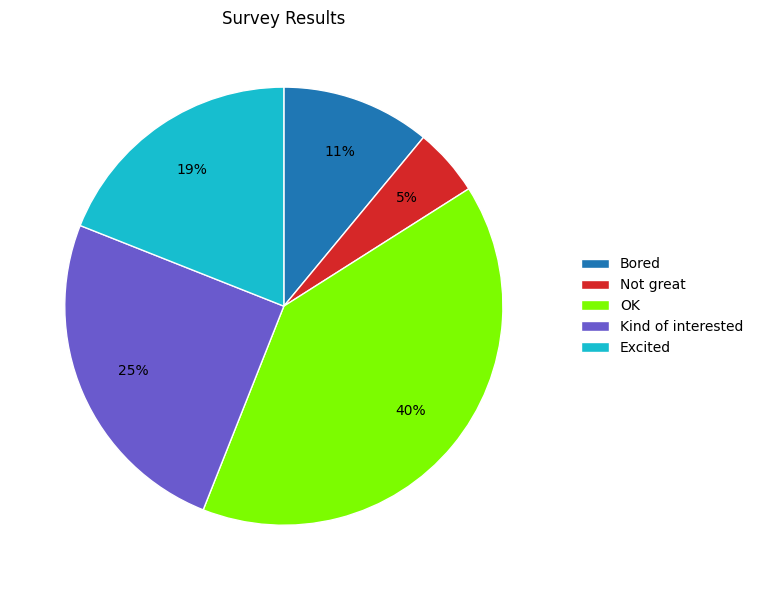

In [10]:
import matplotlib.pyplot as plt

labels = ["Bored", "Not great", "OK", "Kind of interested", "Excited"]
sizes = [11, 5, 40, 25, 19]

colors = ["#1f77b4", "#d62728", "#7CFC00", "#6a5acd", "#17becf"]

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct="%1.0f%%",
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white")
)

ax.set_title("Survey Results")

ax.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()